## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x000001E257D6A2D0> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Peloponnese'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2009-2023_filled_meantemps.csv', encoding=enc)
wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2023.csv', encoding=enc)

In [5]:
timeline_file.head()

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean
0,0,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.859410,37.624530,2009-01-01,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.000000,NaN,0.115554,1,14063.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.859410,37.624530,2009-01-02,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.000000,NaN,29.973920,2,14063.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.859410,37.624530,2009-01-03,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.000000,NaN,49.195785,3,14063.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.859410,37.624530,2009-01-04,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.000000,NaN,7.258097,4,14063.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",21.859410,37.624530,2009-01-05,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14063.000000,NaN,49.884600,5,14063.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
timeline_file.shape

(3889380, 34)

In [7]:
wnv_file.head()

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,πελοποννησος,"αργολιδα, αρκαδια",2017-06,2
1,πελοποννησος,"αργολιδα, αρκαδια",2017-07,30
2,πελοποννησος,"αργολιδα, αρκαδια",2017-08,6
3,πελοποννησος,"αργολιδα, αρκαδια",2017-09,0
4,πελοποννησος,"αργολιδα, αρκαδια",2017-10,0


In [8]:
wnv_file.shape

(45, 4)

In [9]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [10]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)
timeline_file['week'] = timeline_file.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

timeline_file = encode_cyclical(timeline_file, 'day', 31)
timeline_file = encode_cyclical(timeline_file, 'month', 12)
timeline_file = encode_cyclical(timeline_file, 'week', 53)

In [11]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

### Add mosquito predictions from trained model

In [12]:
dataset_list = []
groups = timeline_file.groupby(['x', 'y', 'year'])

for group, data in groups:
    temp_df = data.copy()
    temp_df.reset_index(drop=True, inplace=True)
    temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
    temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
    temp_df['acc_rainfall_month'] = temp_df['rainfall'].rolling(window=30, min_periods=0).sum()
    temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
    dataset_list.append(temp_df)

dataset = pd.concat(dataset_list, ignore_index=True)
dataset.reset_index(drop=True, inplace=True)

In [13]:
dataset.dtypes

Unnamed: 0                     int64
NUTS2_ID                      object
NUTS2_NAME                    object
NUTS3_ID                      object
NUTS3_NAME                    object
x                            float64
y                            float64
dt_placement          datetime64[ns]
year                           int64
month                          int64
ndvi                         float64
ndmi                         float64
ndwi                         float64
ndbi                         float64
ndvi_mean                    float64
ndmi_mean                    float64
ndwi_mean                    float64
ndbi_mean                    float64
ndvi_std                     float64
ndmi_std                     float64
ndwi_std                     float64
ndbi_std                     float64
lst_day                      float64
lst_night                    float64
rainfall                     float64
day                            int64
lst_jan_day_mean             float64
l

In [16]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'rb'))

In [17]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [18]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [19]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [20]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<Axes: >

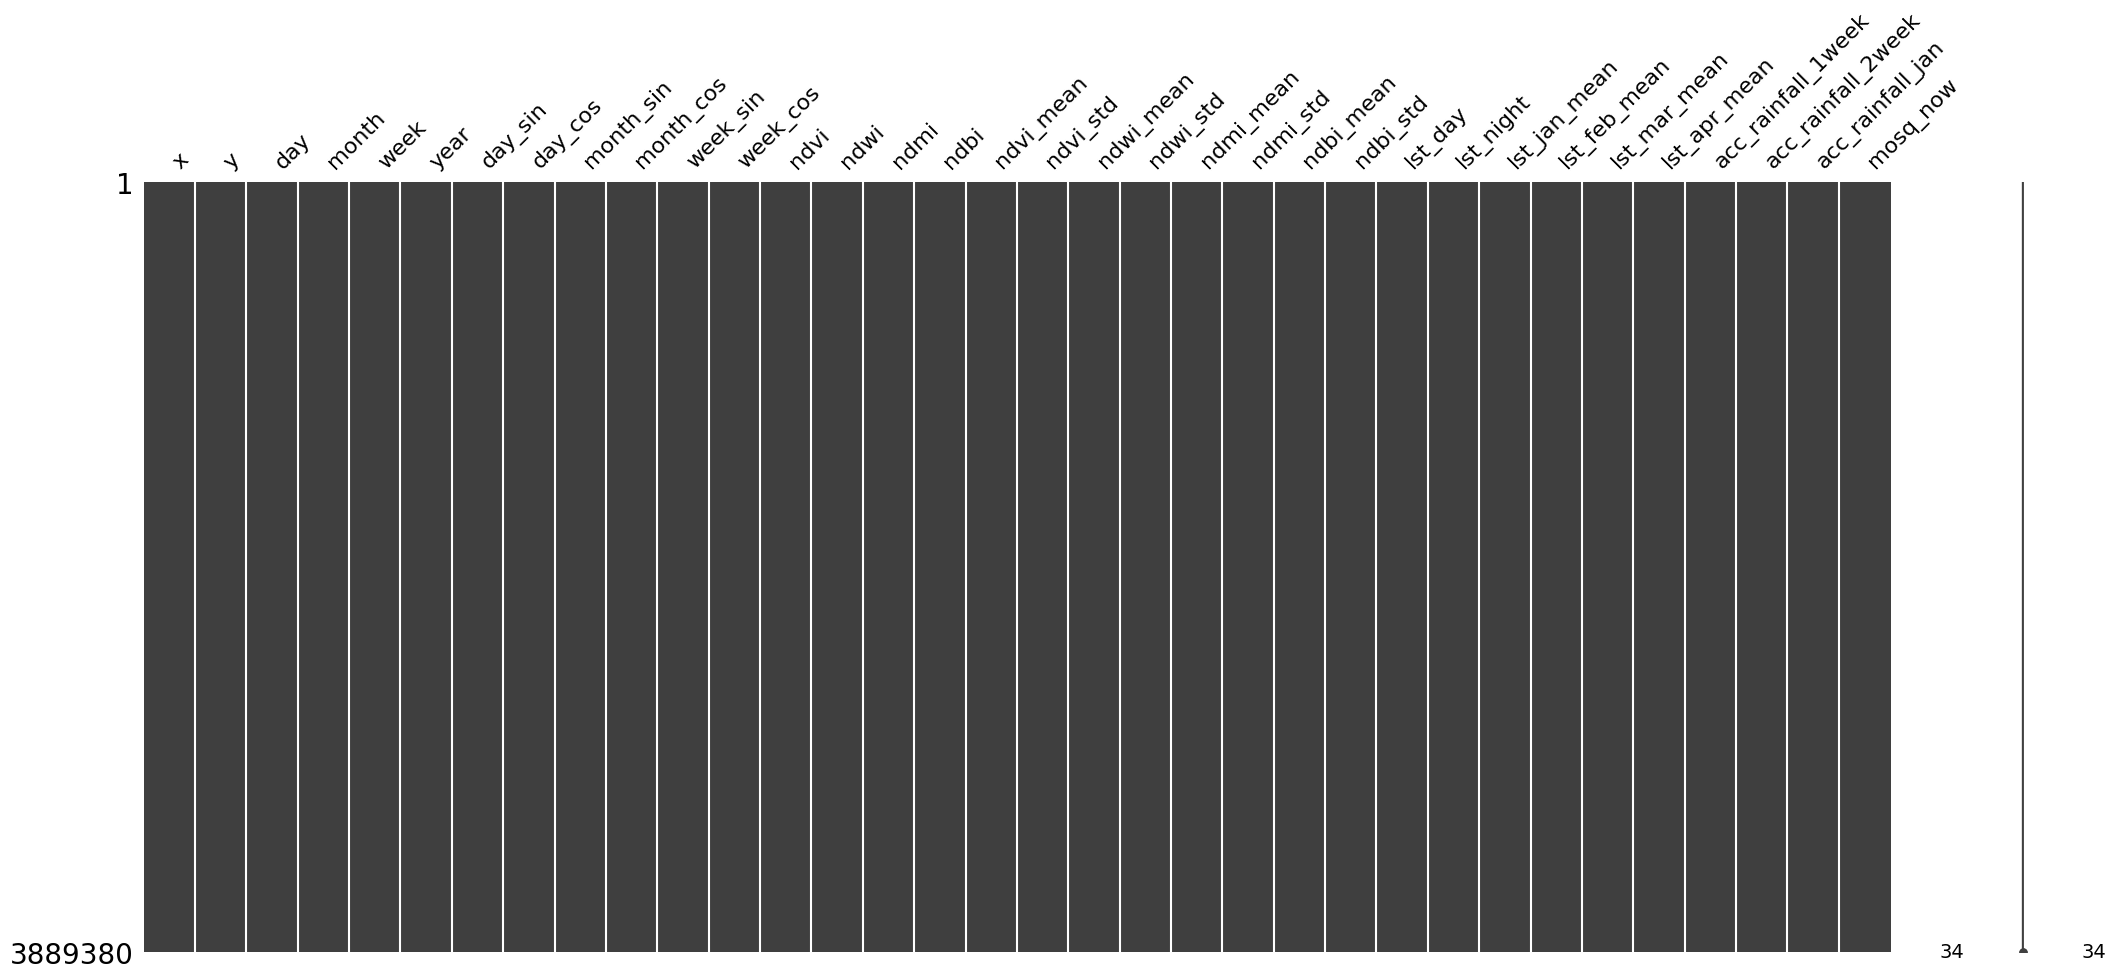

In [21]:
missingno.matrix(dataset_mamoth)

In [22]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [23]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [24]:
predictions = give_predictions(model, dataset_mamoth)

In [25]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.606100,37.092580,2009-01-01,38
1,21.606100,37.092580,2009-01-02,38
2,21.606100,37.092580,2009-01-03,38
3,21.606100,37.092580,2009-01-04,38
4,21.606100,37.092580,2009-01-05,39
...,...,...,...,...
3889375,23.299120,37.444860,2023-12-27,27
3889376,23.299120,37.444860,2023-12-28,27
3889377,23.299120,37.444860,2023-12-29,29
3889378,23.299120,37.444860,2023-12-30,30


<Axes: >

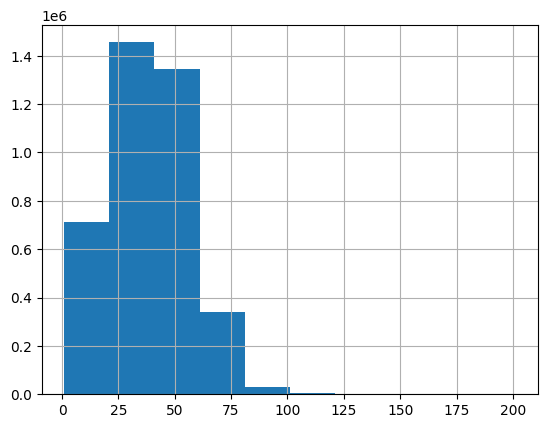

In [26]:
mosqutio_predictions.mosq_pred.hist()

In [28]:
mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc, index = False)

# mosqutio_predictions = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc)
# mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])

#dataset = timeline_file

In [29]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

### Add Geomorphological and Land Cover/Use

In [30]:
dataset

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred
0,28339,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-01,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,38
1,28340,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-02,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,38
2,28341,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-03,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,38
3,28342,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-04,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,38
4,28343,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-05,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,0.000000,0.000000,0.000000,0.000000,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3889375,3859005,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",23.299120,37.444860,2023-12-27,2023,12,0.377530,0.271963,-0.232232,-0.271963,0.329909,0.217584,-0.211422,-0.217584,0.038035,0.079109,0.061823,0.079109,14443.000000,14086.000000,0.000000,27,14318.548387,14308.321429,14633.129032,14633.129032,14000.580645,13900.892857,14067.903226,14067.903226,14264.500000,14159.564516,14104.607143,14350.516129,14350.516129,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,10.809622,56.676354,116.384560,743.656392,27
3889376,3859006,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",23.299120,37.444860,2023-12-28,2023,12,0.377530,0.271963,-0.232232,-0.271963,0.329909,0.217584,-0.211422,-0.217584,0.038035,0.079109,0.061823,0.079109,14451.000000,14089.000000,0.000000,28,14318.548387,14308.321429,14633.129032,14633.129032,14000.580645,13900.892857,14067.903226,14067.903226,14270.000000,14159.564516,14104.607143,14350.516129,14350.516129,52,-0.571268,0.820763,-0.000000,1.000000,-0.118273,0.992981,2.603918,56.331724,113.512984,743.656392,27
3889377,3859007,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",23.299120,37.444860,2023-12-29,2023,12,0.377530,0.271963,-0.232232,-0.271963,0.329909,0.217584,-0.211422,-0.217584,0.038035,0.079109,0.061823,0.079109,14383.000000,14056.000000,0.000000,29,14318.548387,14308.321429,14633.129032,14633.129032,14000.580645,13900.892857,14067.903226,14067.903226,14219.500000,14159.564516,14104.607143,14350.516129,14350.516129,52,-0.394356,0.918958,-0.000000,1.000000,-0.118273,0.992981,0.000000,35.138053,111.962390,743.656392,29
3889378,3859008,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",23.299120,37.444860,2023-12-30,2023,12,0.377530,0.271963,-0.232232,-0.271963,0.329909,0.217584,

In [31]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [32]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [33]:
dataset_locations

,x,y
0,21.606100,37.092580
1,21.606100,37.128520
2,21.606100,37.164450
3,21.650740,37.056650
4,21.650740,37.092580
...,...,...
705,23.209140,37.408930
706,23.209140,37.444860
707,23.209140,37.480800
708,23.254130,37.444860


In [34]:
dataset_locations_per_year

,x,y,year
0,21.606100,37.092580,2009
1,21.606100,37.092580,2010
2,21.606100,37.092580,2011
3,21.606100,37.092580,2012
4,21.606100,37.092580,2013
...,...,...,...
10645,23.299120,37.444860,2019
10646,23.299120,37.444860,2020
10647,23.299120,37.444860,2021
10648,23.299120,37.444860,2022


In [35]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [36]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 2.4013798188209272e-12


In [37]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_5264\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [38]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.606100,37.092580,2093.787722,380.799130,4,235.168312,74.835819,191.487134,0.000000,1.000000
1,21.606100,37.128520,2886.929890,622.046077,6,243.499756,146.368277,195.898542,0.000000,1.687028
2,21.606100,37.164450,3345.256981,1401.545409,9,236.781303,116.713126,189.367651,0.000000,1.009957
3,21.650740,37.056650,4562.909045,2723.733568,7,186.966621,298.671593,181.056447,0.000000,1.000000
4,21.650740,37.092580,6060.769585,130.203318,4,206.893475,289.630969,187.101238,0.000000,60.157255
...,...,...,...,...,...,...,...,...,...,...
705,23.209140,37.408930,3380.275014,509.410933,19,130.024542,69.757991,171.165973,0.000000,3.813032
706,23.209140,37.444860,6609.052046,1585.429716,12,124.863564,246.681022,180.493776,0.000000,1.922152
707,23.209140,37.480800,8197.181506,3429.020938,29,212.393552,967.468680,203.362687,0.000000,1.274440
708,23.254130,37.444860,4415.143779,64.809350,4,186.958077,188.933530,181.039286,0.000000,70.519331


In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [41]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [42]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.606100,37.092580,2093.787722,380.799130,4,235.168312,74.835819,191.487134,0.000000,1.000000
1,21.606100,37.128520,2886.929890,622.046077,6,243.499756,146.368277,195.898542,0.000000,1.687028
2,21.606100,37.164450,3345.256981,1401.545409,9,236.781303,116.713126,189.367651,0.000000,1.009957
3,21.650740,37.056650,4562.909045,2723.733568,7,186.966621,298.671593,181.056447,0.000000,1.000000
4,21.650740,37.092580,6060.769585,130.203318,4,206.893475,289.630969,187.101238,0.000000,60.157255
...,...,...,...,...,...,...,...,...,...,...
705,23.209140,37.408930,3380.275014,509.410933,19,130.024542,69.757991,171.165973,0.000000,3.813032
706,23.209140,37.444860,6609.052046,1585.429716,12,124.863564,246.681022,180.493776,0.000000,1.922152
707,23.209140,37.480800,8197.181506,3429.020938,29,212.393552,967.468680,203.362687,0.000000,1.274440
708,23.254130,37.444860,4415.143779,64.809350,4,186.958077,188.933530,181.039286,0.000000,70.519331


In [43]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [44]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [45]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [46]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [47]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [48]:
landcover_2023 = landcover_2022

In [49]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2010
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2011
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2012
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2013
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2014
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2015
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2016
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2017
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2018
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2019
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2020
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2021
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2022
Min distance: 0.0
Max distance: 2.4013798188209272e-12
Year: 2023
Min distance: 0.0
Max distance: 2.4013798188209272e-12


In [50]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [51]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.606100,37.092580,2009,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
1,21.606100,37.128520,2009,22,96,20,96.000000,20,96,9,9,4,2,2,2,0
2,21.606100,37.164450,2009,31,96,30,96.000000,30,96,10,10,1,6,6,2,0
3,21.650740,37.056650,2009,22,85,20,85.000000,20,85,9,9,4,2,2,2,0
4,21.650740,37.092580,2009,22,94,20,94.000000,20,94,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10645,23.209140,37.408930,2023,31,96,30,96.000000,30,96,10,10,1,6,6,2,0
10646,23.209140,37.444860,2023,31,88,30,88.000000,30,88,10,10,1,6,6,2,0
10647,23.209140,37.480800,2023,22,84,20,84.000000,20,84,9,9,4,1,1,2,0
10648,23.254130,37.444860,2023,22,77,20,77.000000,20,77,9,9,4,1,1,2,0


In [52]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [53]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [54]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [55]:
dataset

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,28339,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-01,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,38,2093.787722,380.799130,4,235.168312,74.835819,191.487134,0.000000,1.000000,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
1,28340,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-02,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,38,2093.787722,380.799130,4,235.168312,74.835819,191.487134,0.000000,1.000000,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
2,28341,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-03,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,38,2093.787722,380.799130,4,235.168312,74.835819,191.487134,0.000000,1.000000,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
3,28342,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-04,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,38,2093.787722,380.799130,4,235.168312,74.835819,191.487134,0.000000,1.000000,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
4,28343,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21.606100,37.092580,2009-01-05,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.848644,0.528964,0.500000,0.866025,0.234886,0.972023,0.000000,0.000000,0.000000,0.000000,39,2093.787722,380.799130,4,235.168312,74.835819,191.487134,0.000000,1.000000,22,87,20,87.000000,20,87,9,9,4,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3889375,3859005,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",23.299120,37.444860,2023-12-27,2023,12,0.377530,0.271963,-0.232232,-0.271963,0.329909,0.217584,-0.211422,-0.217584,0.038035,0.079109,0.061823,0.079109,14443.000000,14086.000000,0.000000,27,14318.548387,14308.321429,14633.129032,14633.129032,14000.580645,13900.892857,14067.903226,14067.903226,14264.500000,14159.564516,14104.607143,14350.516129,14350.516129,52,-0.724793,0.688967,-0.000000,1.000000,-0.118273,0.992981,10.809622,56.676354,116.384560,743.656392,27,4078.056840,339.527668,5,164.893174,206.505410,178.170574,0.000000,19.966357,22,77,20,77.000000,20,77,9,9,4,1,1,2,0
3889376,3859006,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",23.299120,37.444860,2023-12-28,2023,12,0.377530,0.271963,-0.232232,-0.271963,0.329909,0.217584,-0.

In [56]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [57]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [58]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [59]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [60]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [61]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,Unnamed: 0,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",0,22.174340,37.624530,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14014.000000,13651.000000,0.000000,1,14014.000000,NaN,NaN,NaN,13651.000000,NaN,NaN,NaN,13634.000000,13634.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,25,161.346303,2.484012,4,33.961507,9.807387,131.548032,0.000000,1.000000,31,85,20,85.000000,20,85,9,9,4,1,1,2,0
1,2009-01-01,EL65,πελοποννησος,EL652,κορινθια,9734,22.426810,37.900180,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13563.000000,13672.000000,0.964036,1,13563.000000,NaN,NaN,NaN,13672.000000,NaN,NaN,NaN,13894.500000,13894.500000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.964036,0.964036,0.964036,0.964036,23,2628.106643,38.115455,7,51.056323,45.272061,141.900829,0.000000,1.000000,31,89,20,89.000000,30,89,9,9,1,1,1,2,0
2,2009-01-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21984,22.454240,37.092580,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14090.000000,13658.000000,0.000000,1,14090.000000,NaN,NaN,NaN,13658.000000,NaN,NaN,NaN,13816.000000,13816.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,29,1837.803022,14.353368,4,47.835132,2.194627,120.510224,0.000000,1.000000,22,87,20,86.000000,20,86,9,9,4,1,1,2,0
3,2009-01-02,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",1,22.174340,37.624530,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14014.000000,13651.000000,0.000000,2,14014.000000,NaN,NaN,NaN,13651.000000,NaN,NaN,NaN,13634.000000,13634.000000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,27,161.346303,2.484012,4,33.961507,9.807387,131.548032,0.000000,1.000000,31,85,20,85.000000,20,85,9,9,4,1,1,2,0
4,2009-01-02,EL65,πελοποννησος,EL652,κορινθια,9735,22.426810,37.900180,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13566.000000,13672.000000,10.508551,2,13947.000000,NaN,NaN,NaN,13672.000000,NaN,NaN,NaN,13894.500000,13894.500000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,11.472587,11.472587,11.472587,11.472587,22,2628.106643,38.115455,7,51.056323,45.272061,141.900829,0.000000,1.000000,31,89,20,89.000000,30,89,9,9,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16429,2023-12-30,EL65,πελοποννησος,EL652,κορινθια,3865673,22.426810,37.900180,2023,12,-0.022222,-0.051691,-0.504554,-0.620758,0.083700,-0.057879,-0.457085,-0.525287,0.000000,0.000000,0.000000,0.000000,14058.000000,13939.000000,0.000000,30,13693.903226,13697.214286,13988.096774,13988.096774,13480.903226,13369.000000,13618.322581,13618.322581,14124.500000,13648.177419,13545.071429,13837.741935,13837.741935,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,0.000000,7.695558,110.368470,1123.670238,26,2628.106643,38.115455,7,51.056323,45.272061,141.900829,0.00

In [62]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,Unnamed: 0,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2009-01-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",0,21.859410,37.049600,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13498.000000,13508.000000,0.000000,1,13498.000000,NaN,NaN,NaN,13508.000000,NaN,NaN,NaN,13600.000000,13600.000000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,15,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,11,67,10,66.000000,10,66,1,1,1,1,1,2,0
1,2009-01-01,EL65,πελοποννησος,EL652,κορινθια,9734,22.290560,37.756440,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13394.000000,13499.000000,0.000000,1,13394.000000,NaN,NaN,NaN,13499.000000,NaN,NaN,NaN,13603.500000,13603.500000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,8,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,11,66,9,66.000000,10,66,1,1,1,1,1,2,0
2,2009-01-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",21984,21.606100,36.481710,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13669.000000,13473.000000,0.000000,1,13669.000000,NaN,NaN,NaN,13473.000000,NaN,NaN,NaN,13653.500000,13653.500000,NaN,NaN,NaN,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,24,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.000000,1.000000,11,67,10,67.000000,10,67,1,1,1,1,1,2,0
3,2009-01-02,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",1,21.859410,37.049600,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13498.000000,13508.000000,0.000000,2,13498.000000,NaN,NaN,NaN,13508.000000,NaN,NaN,NaN,13600.000000,13600.000000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,0.000000,0.000000,0.000000,0.000000,1,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,11,67,10,66.000000,10,66,1,1,1,1,1,2,0
4,2009-01-02,EL65,πελοποννησος,EL652,κορινθια,9735,22.290560,37.756440,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13394.000000,13499.000000,3.316053,2,13394.000000,NaN,NaN,NaN,13499.000000,NaN,NaN,NaN,13603.500000,13603.500000,NaN,NaN,NaN,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,3.562428,3.562428,3.562428,3.562428,1,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,11,66,9,66.000000,10,66,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16429,2023-12-30,EL65,πελοποννησος,EL652,κορινθια,3865673,22.290560,37.756440,2023,12,-0.022222,-0.051691,-0.504554,-0.620758,0.083700,-0.057879,-0.457085,-0.525287,0.000000,0.000000,0.000000,0.000000,13798.000000,13620.000000,0.000000,30,13693.903226,13697.214286,13988.096774,13988.096774,13480.903226,13369.000000,13618.322581,13618.322581,13715.000000,13648.177419,13545.071429,13837.741935,13837.741935,52,-0.201299,0.979530,-0.000000,1.000000,-0.118273,0.992981,0.000000,2.851885,37.646819,578.240541,16,2628.106643,38.115455,1,51.056323,45.27

In [63]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean','lst_night','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_nuts3_mean[['rainfall','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan', 'mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [64]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2009-01-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13920.190141,13920.190141,NaN,NaN,NaN,13694.006993,13694.006993,NaN,NaN,NaN,13837.156028,13837.156028,NaN,NaN,NaN,0.398227,0.398227,0.398227,0.398227,0.398227,28.420382,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2
1,2009-01-01,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13878.071429,13878.071429,NaN,NaN,NaN,13758.956522,13758.956522,NaN,NaN,NaN,13859.065217,13859.065217,NaN,NaN,NaN,0.719646,0.719646,0.719646,0.719646,0.719646,22.764045,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,31,20,30,9,9,1,1,1,2
2,2009-01-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.303892,36.998594,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14107.795918,14107.795918,NaN,NaN,NaN,13739.026316,13739.026316,NaN,NaN,NaN,13936.526316,13936.526316,NaN,NaN,NaN,0.018079,0.018079,0.018079,0.018079,0.018079,32.524430,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.000000,1.000000,33187.044169,4566.578852,52,312.154021,1632.386902,220.135393,0.000000,839.669847,7776.311459,953.263755,10.133277,55.424007,349.428395,15.049726,0.000000,87.983581,22,20,20,9,9,4,1,1,2
3,2009-01-02,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13919.278169,13919.734155,NaN,NaN,NaN,13694.006993,13694.006993,NaN,NaN,NaN,13837.156028,13837.156028,NaN,NaN,NaN,10.307556,10.705783,10.705783,10.705783,10.705783,26.452229,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2
4,2009-01-02,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13886.273810,13882.172619,NaN,NaN,NaN,13758.956522,13758.956522,NaN,NaN,NaN,13862.586957,138

<Axes: >

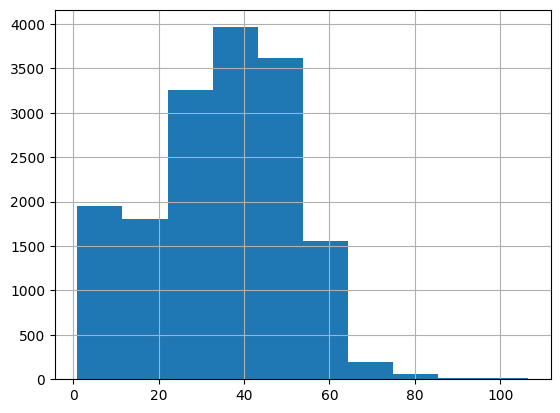

In [65]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [66]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<Axes: >

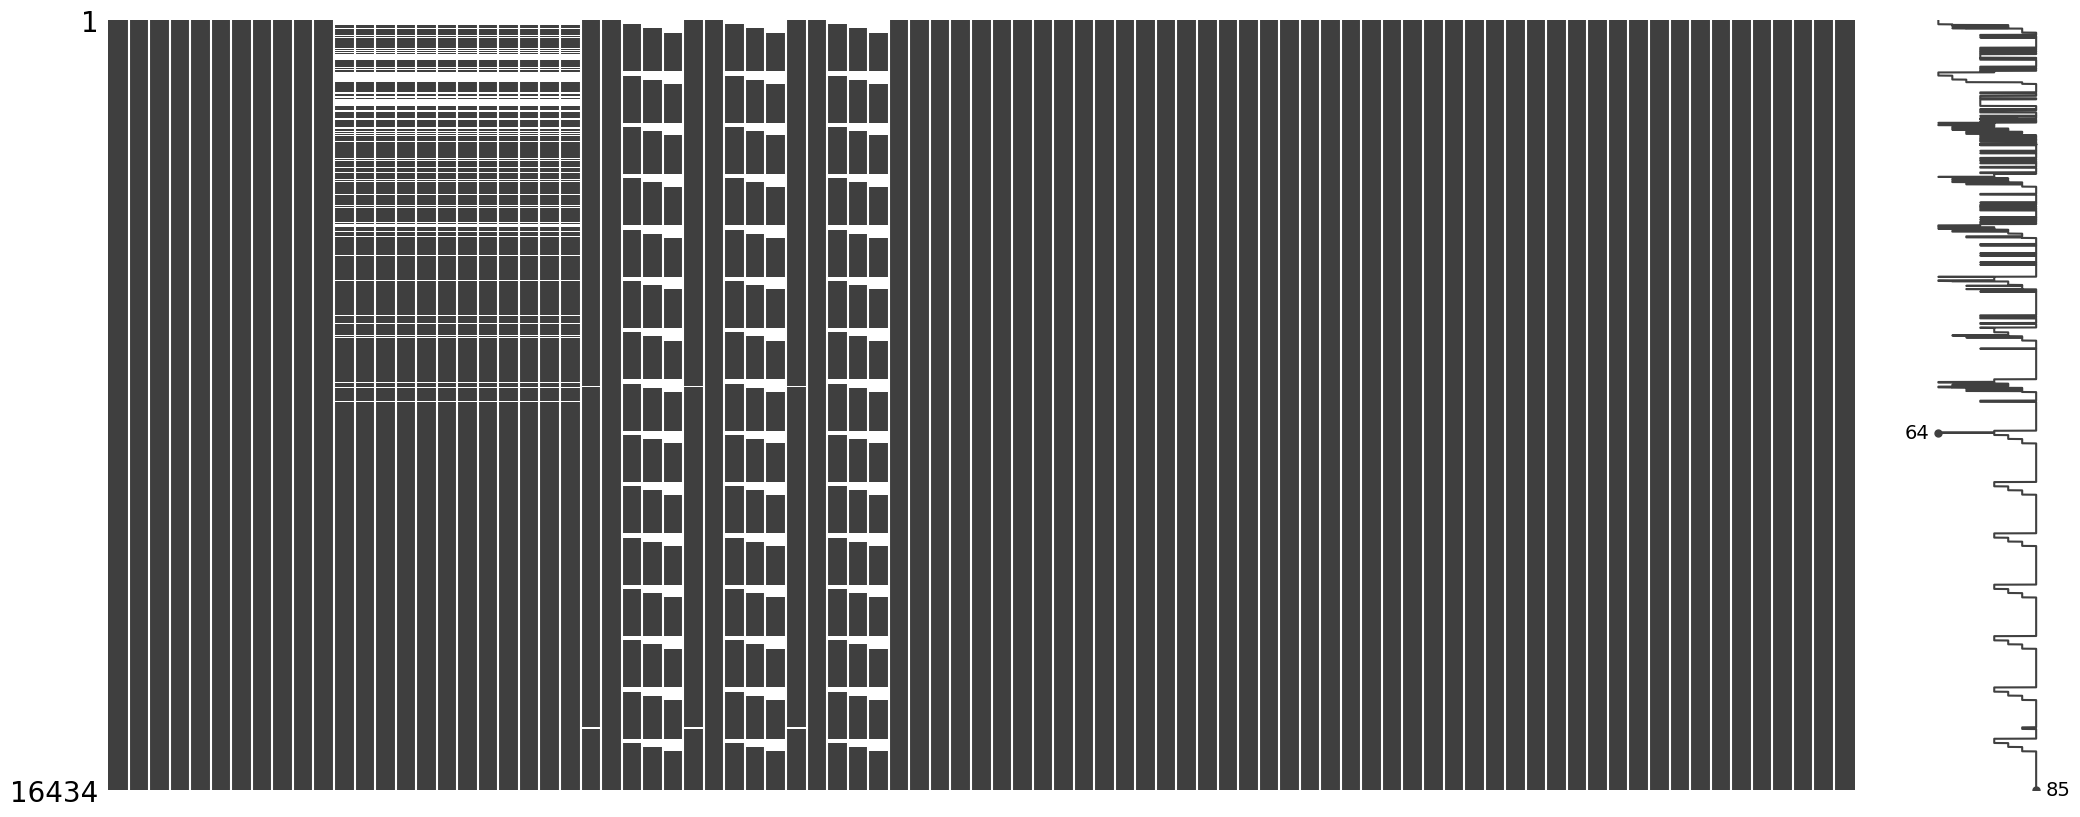

In [67]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [68]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [69]:
bio_values_df = pd.DataFrame(bio_values)

In [70]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,"αργολιδα, αρκαδια",2009,1,-0.005235,12.169443,326.884315
1,"αργολιδα, αρκαδια",2009,2,-2.126934,12.025679,185.003318
2,"αργολιδα, αρκαδια",2009,3,0.171189,19.056690,172.226710
3,"αργολιδα, αρκαδια",2009,4,2.827422,25.015157,87.902149
4,"αργολιδα, αρκαδια",2009,5,7.300941,34.558711,33.075850
...,...,...,...,...,...,...
535,"λακωνια, μεσσηνια",2023,8,20.434082,39.840204,2.221974
536,"λακωνια, μεσσηνια",2023,9,17.052449,33.280204,15.781725
537,"λακωνια, μεσσηνια",2023,10,13.397755,27.990408,6.915586
538,"λακωνια, μεσσηνια",2023,11,4.132449,25.132857,32.260579


In [71]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [72]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.253803,5.253803,NaN,NaN,NaN,0.730140,0.730140,NaN,NaN,NaN,2.991971,3.593121,NaN,NaN,NaN,0.398227,0.398227,0.398227,0.398227,0.398227,28.420382,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315
1,2009-01-01,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.411429,4.411429,NaN,NaN,NaN,2.029130,2.029130,NaN,NaN,NaN,3.220280,4.031304,NaN,NaN,NaN,0.719646,0.719646,0.719646,0.719646,0.719646,22.764045,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,31,20,30,9,9,1,1,1,2,0.961290,12.433820,283.656469
2,2009-01-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.303892,36.998594,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.005918,9.005918,NaN,NaN,NaN,1.630526,1.630526,NaN,NaN,NaN,5.318222,5.580526,NaN,NaN,NaN,0.018079,0.018079,0.018079,0.018079,0.018079,32.524430,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.000000,1.000000,33187.044169,4566.578852,52,312.154021,1632.386902,220.135393,0.000000,839.669847,7776.311459,953.263755,10.133277,55.424007,349.428395,15.049726,0.000000,87.983581,22,20,20,9,9,4,1,1,2,1.630526,13.933265,73.872681
3,2009-01-02,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.235563,5.244683,NaN,NaN,NaN,0.730140,0.730140,NaN,NaN,NaN,2.982852,3.593121,NaN,NaN,NaN,10.307556,10.705783,10.705783,10.705783,10.705783,26.452229,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315
4,2009-01-02,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.575476,4.493452,

<Axes: >

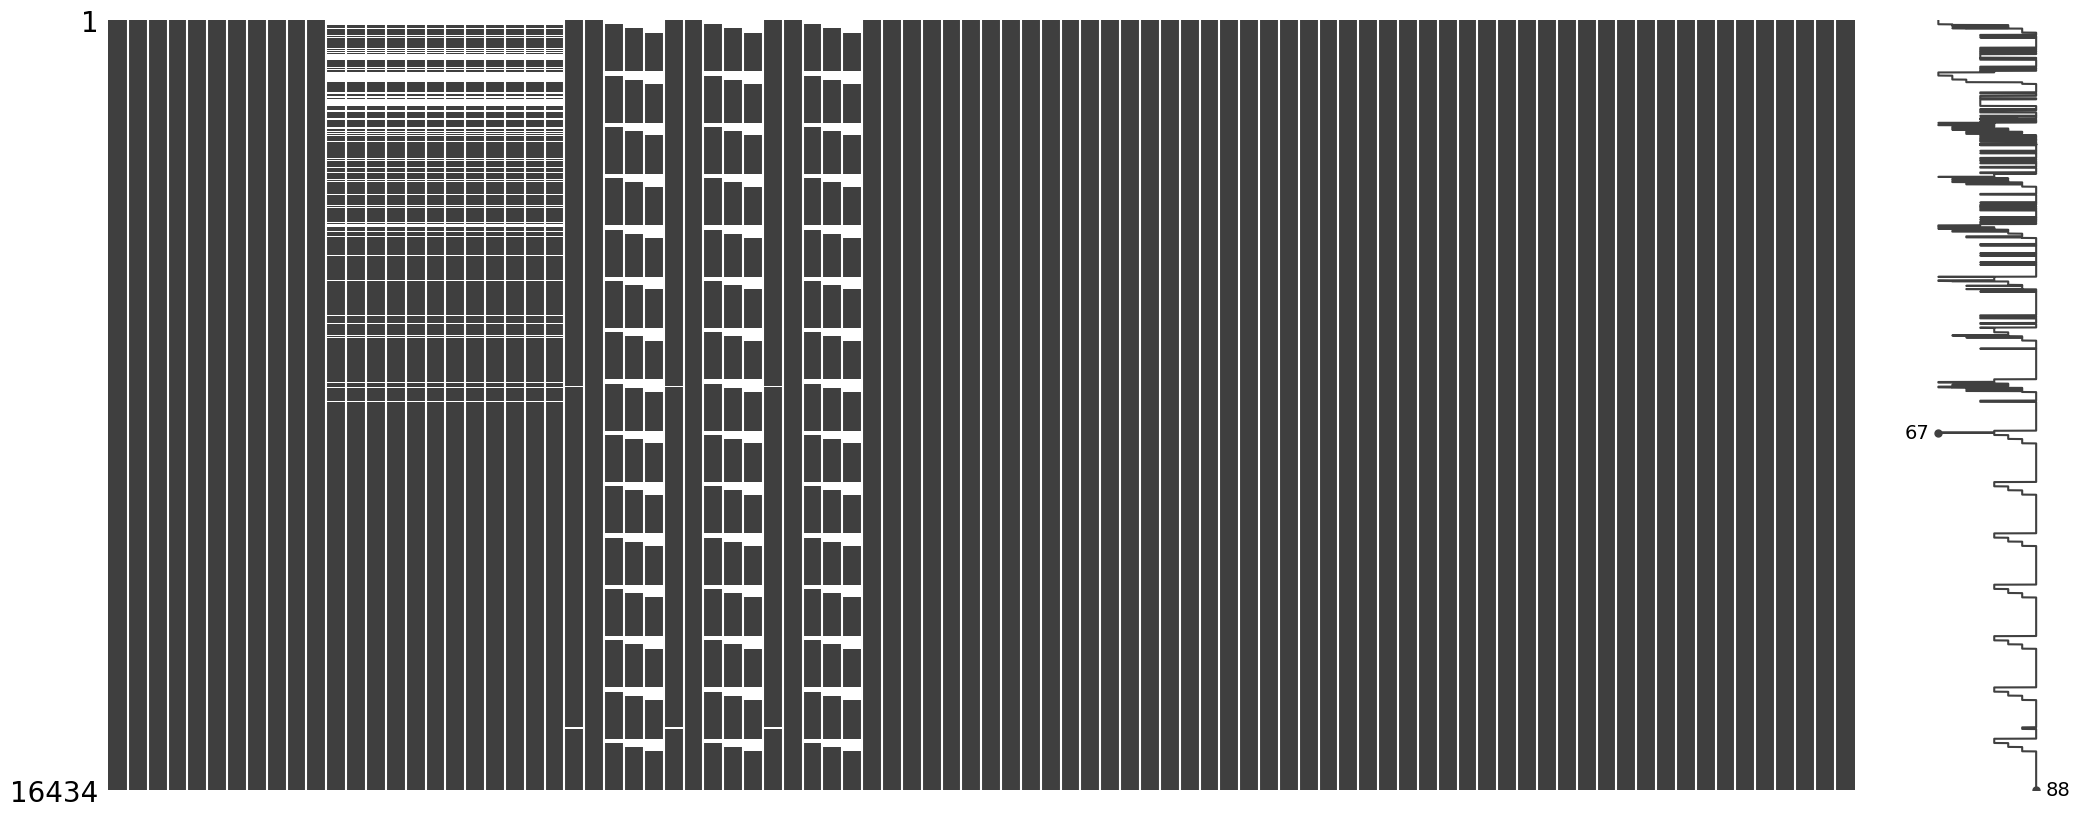

In [73]:
missingno.matrix(dataset)

In [74]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [75]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [76]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2009-01-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.253803,5.253803,NaN,NaN,NaN,0.730140,0.730140,NaN,NaN,NaN,2.991971,3.593121,NaN,NaN,NaN,0.398227,0.398227,0.398227,0.398227,0.398227,28.420382,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315,2009-01
1,2009-01-01,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.411429,4.411429,NaN,NaN,NaN,2.029130,2.029130,NaN,NaN,NaN,3.220280,4.031304,NaN,NaN,NaN,0.719646,0.719646,0.719646,0.719646,0.719646,22.764045,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,31,20,30,9,9,1,1,1,2,0.961290,12.433820,283.656469,2009-01
2,2009-01-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.303892,36.998594,1,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.005918,9.005918,NaN,NaN,NaN,1.630526,1.630526,NaN,NaN,NaN,5.318222,5.580526,NaN,NaN,NaN,0.018079,0.018079,0.018079,0.018079,0.018079,32.524430,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.000000,1.000000,33187.044169,4566.578852,52,312.154021,1632.386902,220.135393,0.000000,839.669847,7776.311459,953.263755,10.133277,55.424007,349.428395,15.049726,0.000000,87.983581,22,20,20,9,9,4,1,1,2,1.630526,13.933265,73.872681,2009-01
3,2009-01-02,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,2,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.235563,5.244683,NaN,NaN,NaN,0.730140,0.730140,NaN,NaN,NaN,2.982852,3.593121,NaN,NaN,NaN,10.307556,10.705783,10.705783,10.705783,10.705783,26.452229,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315,2009-01
4,2009-01-02,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,2,1,2009,1,NaN,NaN,NaN,NaN

In [77]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2009-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.089789,5.244683,NaN,NaN,NaN,0.730140,0.730140,NaN,NaN,NaN,3.212316,3.593121,NaN,NaN,NaN,0.084207,0.398227,0.398227,0.398227,0.398227,3.082803,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315
1,1,2009-01,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.904545,4.411429,NaN,NaN,NaN,2.029130,2.029130,NaN,NaN,NaN,3.432918,4.031304,NaN,NaN,NaN,0.541723,0.719646,0.719646,0.719646,0.719646,1.078652,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,31,20,30,9,9,1,1,1,2,0.961290,12.433820,283.656469
2,2,2009-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.303892,36.998594,1,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.929592,8.942313,NaN,NaN,NaN,7.252857,1.630526,NaN,NaN,NaN,6.560727,5.547719,NaN,NaN,NaN,0.018079,0.018079,0.018079,0.018079,0.018079,27.811075,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.000000,1.000000,33187.044169,4566.578852,52,312.154021,1632.386902,220.135393,0.000000,839.669847,7776.311459,953.263755,10.133277,55.424007,349.428395,15.049726,0.000000,87.983581,22,20,20,9,9,4,1,1,2,1.630526,13.933265,73.872681
3,3,2009-02,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,2,2009,6,0.301841,0.136013,-0.133268,-0.136013,0.293680,0.141811,-0.117988,-0.141811,0.019497,0.025162,0.030835,0.025162,6.546934,8.798801,8.670348,NaN,NaN,-2.126934,3.135829,1.809721,NaN,NaN,5.240035,5.967315,5.240035,NaN,NaN,0.244145,21.162798,45.643648,201.343084,350.435895,2.643312,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-2.126934,12.025679,185.003318
4,4,2009-02,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.91269

In [78]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME', 'x', 'y', 'month', 'year']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_sum[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_acc'}),
                                     grouped_by_month_mean[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_mean'}),
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [79]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2009-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.794372,2.906276,5.850324,8.798801,NaN,NaN,NaN,3.135829,NaN,NaN,NaN,5.967315,NaN,NaN,NaN,10.544655,97.275135,162.097517,326.486088,326.884315,325.385350,10.496302,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315
1,2009-01,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.894878,3.788358,5.841618,7.915540,NaN,NaN,NaN,4.144929,NaN,NaN,NaN,6.030234,NaN,NaN,NaN,9.150209,57.888997,130.297894,282.936824,283.656469,279.573034,9.018485,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,31,20,30,9,9,1,1,1,2,0.961290,12.433820,283.656469
2,2009-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.303892,36.998594,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.877874,5.112057,7.994965,10.877874,NaN,NaN,NaN,5.175483,NaN,NaN,NaN,8.026678,NaN,NaN,NaN,2.382990,22.702147,30.768818,73.854602,73.872681,952.162866,30.714931,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.000000,1.000000,33187.044169,4566.578852,52,312.154021,1632.386902,220.135393,0.000000,839.669847,7776.311459,953.263755,10.133277,55.424007,349.428395,15.049726,0.000000,87.983581,22,20,20,9,9,4,1,1,2,1.630526,13.933265,73.872681
3,2009-02,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,2,2009,0.301841,0.136013,-0.133268,-0.136013,0.293680,0.141811,-0.117988,-0.141811,0.019497,0.025162,0.030835,0.025162,8.742830,1.275127,5.008978,8.798801,8.742830,NaN,NaN,3.135829,1.275127,NaN,NaN,5.967315,5.008978,NaN,NaN,6.607261,24.047503,45.643648,201.343084,511.887633,121.697452,4.346338,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-2.126934,12.025679,185.00331

In [80]:
wnv_file.head(5)

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,πελοποννησος,"αργολιδα, αρκαδια",2017-06,2
1,πελοποννησος,"αργολιδα, αρκαδια",2017-07,30
2,πελοποννησος,"αργολιδα, αρκαδια",2017-08,6
3,πελοποννησος,"αργολιδα, αρκαδια",2017-09,0
4,πελοποννησος,"αργολιδα, αρκαδια",2017-10,0


In [81]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 87 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            540 non-null    period[M]
 1   NUTS2_ID                540 non-null    object   
 2   NUTS2_NAME              540 non-null    object   
 3   NUTS3_ID                540 non-null    object   
 4   NUTS3_NAME              540 non-null    object   
 5   x                       540 non-null    float64  
 6   y                       540 non-null    float64  
 7   month                   540 non-null    int64    
 8   year                    540 non-null    int64    
 9   ndvi                    531 non-null    float64  
 10  ndmi                    531 non-null    float64  
 11  ndwi                    531 non-null    float64  
 12  ndbi                    531 non-null    float64  
 13  ndvi_mean               531 non-null    float64  
 14  ndmi_mean 

In [82]:
wnv_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   NUTS2_NAME    45 non-null     object
 1   NUTS3_NAME    45 non-null     object
 2   dt_placement  45 non-null     object
 3   cases         45 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 1.5+ KB


In [83]:
wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [84]:
wnv_file

,NUTS2_NAME,NUTS3_NAME,dt_placement,cases
0,πελοποννησος,"αργολιδα, αρκαδια",2017-06,2
1,πελοποννησος,"αργολιδα, αρκαδια",2017-07,30
2,πελοποννησος,"αργολιδα, αρκαδια",2017-08,6
3,πελοποννησος,"αργολιδα, αρκαδια",2017-09,0
4,πελοποννησος,"αργολιδα, αρκαδια",2017-10,0
5,πελοποννησος,"αργολιδα, αρκαδια",2018-06,0
6,πελοποννησος,"αργολιδα, αρκαδια",2018-07,0
7,πελοποννησος,"αργολιδα, αρκαδια",2018-08,1
8,πελοποννησος,"αργολιδα, αρκαδια",2018-09,0
9,πελοποννησος,"αργολιδα, αρκαδια",2018-10,0


In [85]:
wnv_file['cases'].value_counts()

cases
0     36
1      5
2      2
30     1
6      1
Name: count, dtype: int64

In [86]:
wnv_file.cases.sum()

45

In [87]:
merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )

In [88]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2009-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.794372,2.906276,5.850324,8.798801,NaN,NaN,NaN,3.135829,NaN,NaN,NaN,5.967315,NaN,NaN,NaN,10.544655,97.275135,162.097517,326.486088,326.884315,325.385350,10.496302,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315,NaN
1,2009-01,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.894878,3.788358,5.841618,7.915540,NaN,NaN,NaN,4.144929,NaN,NaN,NaN,6.030234,NaN,NaN,NaN,9.150209,57.888997,130.297894,282.936824,283.656469,279.573034,9.018485,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,31,20,30,9,9,1,1,1,2,0.961290,12.433820,283.656469,NaN
2,2009-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.303892,36.998594,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.877874,5.112057,7.994965,10.877874,NaN,NaN,NaN,5.175483,NaN,NaN,NaN,8.026678,NaN,NaN,NaN,2.382990,22.702147,30.768818,73.854602,73.872681,952.162866,30.714931,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.000000,1.000000,33187.044169,4566.578852,52,312.154021,1632.386902,220.135393,0.000000,839.669847,7776.311459,953.263755,10.133277,55.424007,349.428395,15.049726,0.000000,87.983581,22,20,20,9,9,4,1,1,2,1.630526,13.933265,73.872681,NaN
3,2009-02,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,2,2009,0.301841,0.136013,-0.133268,-0.136013,0.293680,0.141811,-0.117988,-0.141811,0.019497,0.025162,0.030835,0.025162,8.742830,1.275127,5.008978,8.798801,8.742830,NaN,NaN,3.135829,1.275127,NaN,NaN,5.967315,5.008978,NaN,NaN,6.607261,24.047503,45.643648,201.343084,511.887633,121.697452,4.346338,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-2.126934,1

In [89]:
merged = fillna(merged,{'cases': 0})

In [90]:
merged['cases'].value_counts()

cases
0.000000     546
1.000000       5
2.000000       2
30.000000      1
6.000000       1
Name: count, dtype: int64

In [91]:
merged.cases.sum()

45.0

In [92]:
merged = merged.astype({'cases': 'int'})

<Axes: >

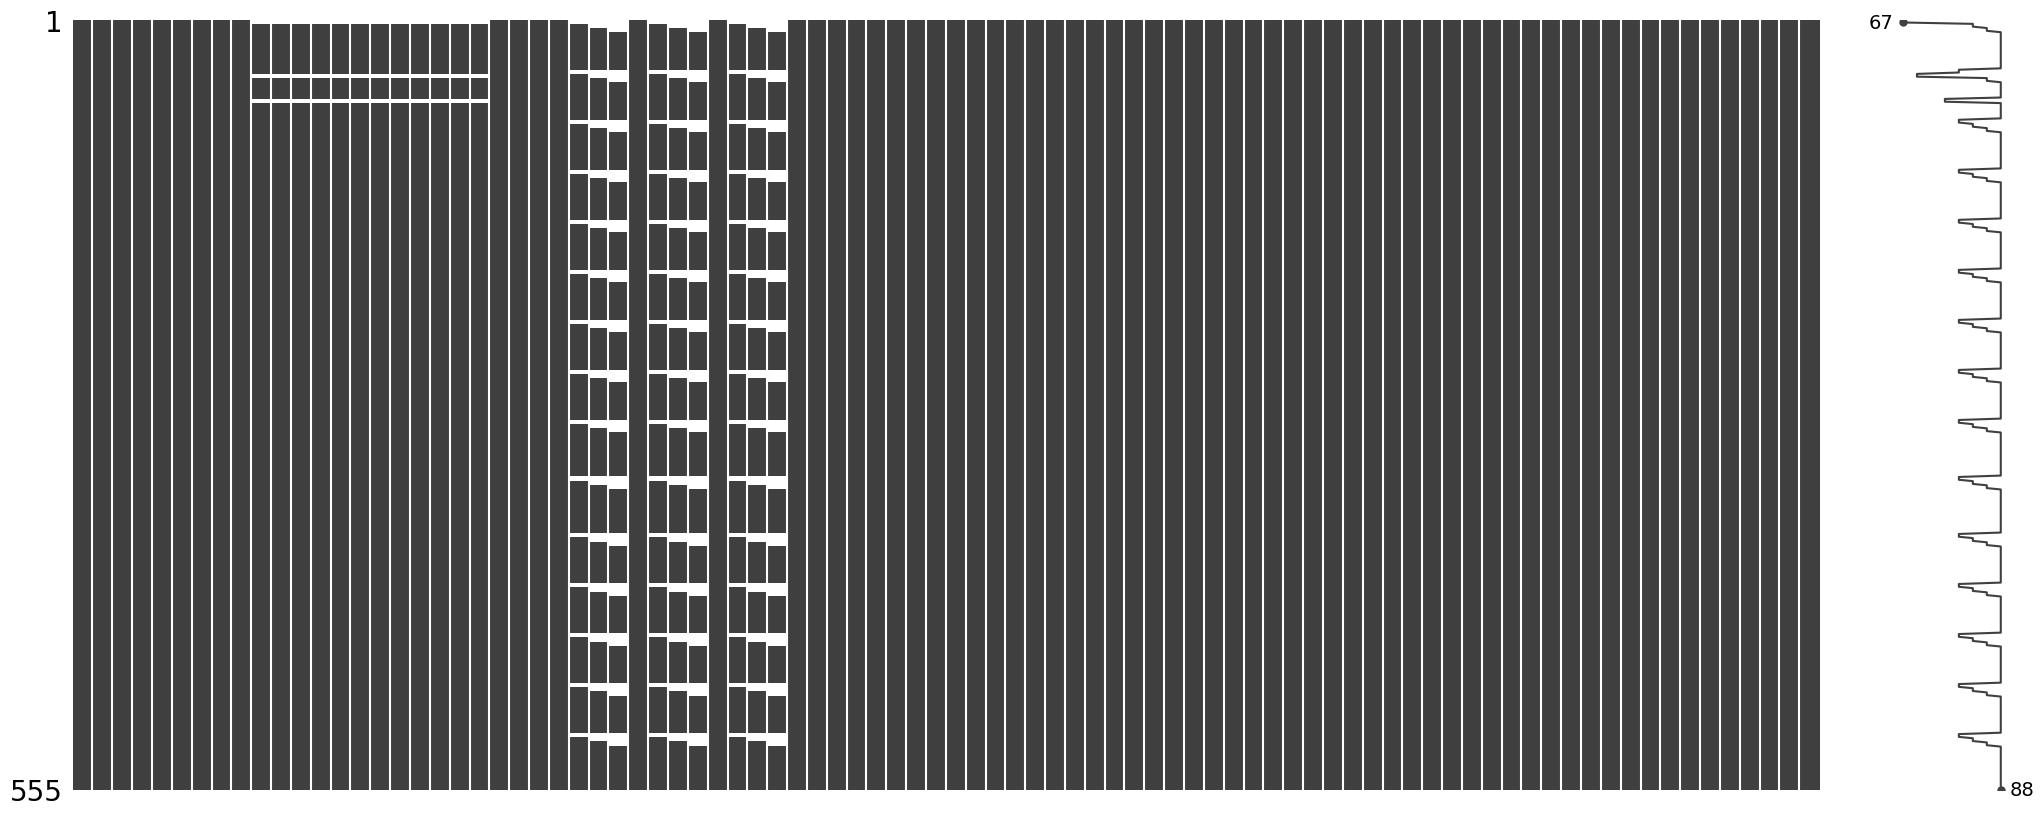

In [93]:
missingno.matrix(merged)

In [94]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

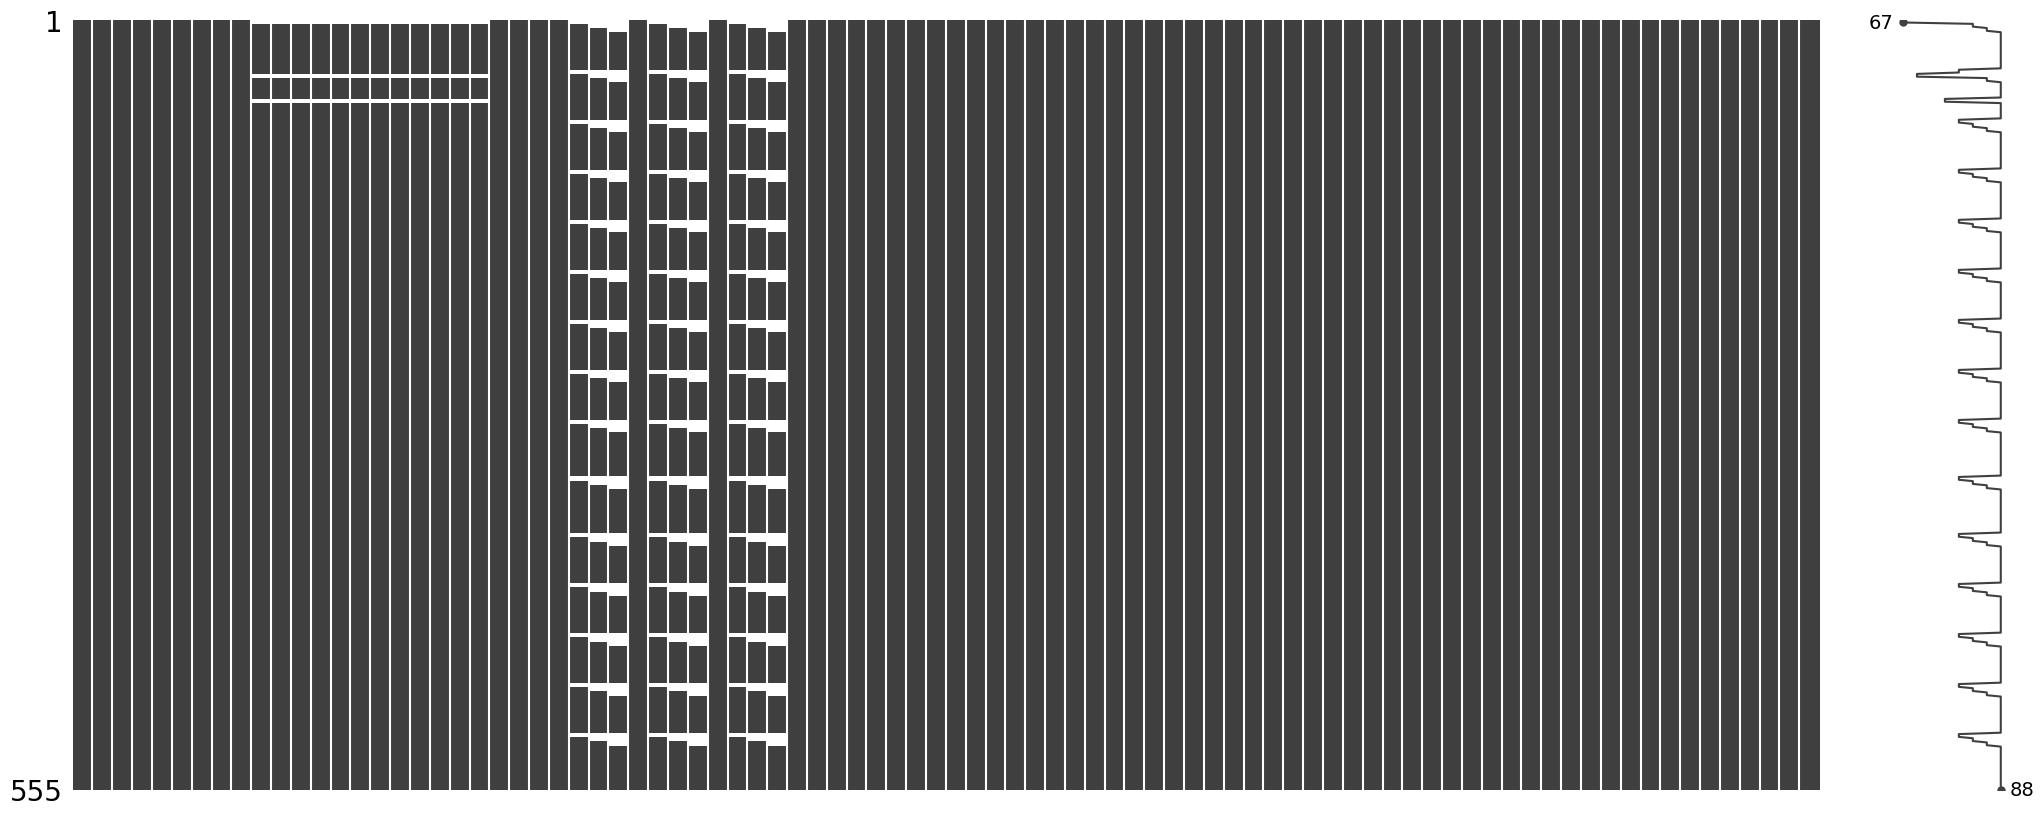

In [95]:
missingno.matrix(merged)

In [96]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023], dtype=int64)

In [97]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['αργολιδα, αρκαδια', 'κορινθια', 'λακωνια, μεσσηνια'], dtype=object)

In [98]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [99]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"αργολιδα, αρκαδια",2009,16.541667,20.083333,42.730496,870.594972,45.000000,-2.000000,47.000000,6.833333,27.833333,27.833333,6.833333,1562.000000,326.000000,12.000000,72.771443,683.000000,74.000000,74.000000,683.000000
1,κορινθια,2009,16.708333,20.083333,43.659420,877.615140,45.000000,-1.000000,46.000000,7.166667,28.166667,28.166667,6.833333,1438.000000,283.000000,16.000000,70.846963,625.000000,69.000000,69.000000,614.000000
2,"λακωνια, μεσσηνια",2009,18.000000,19.333333,43.939394,866.550109,44.000000,0.000000,44.000000,8.333333,26.666667,29.000000,8.000000,291.000000,73.000000,0.000000,83.946894,141.000000,6.000000,7.000000,137.000000
3,"αργολιδα, αρκαδια",2010,17.375000,20.416667,47.480620,806.542847,41.000000,-2.000000,43.000000,7.666667,27.833333,27.833333,7.666667,965.000000,208.000000,0.000000,75.984638,394.000000,85.000000,85.000000,394.000000
4,κορινθια,2010,17.333333,20.666667,49.206349,802.930240,41.000000,-1.000000,42.000000,17.333333,28.000000,28.000000,7.833333,996.000000,232.000000,0.000000,77.707436,385.000000,92.000000,92.000000,372.000000
5,"λακωνια, μεσσηνια",2010,18.916667,20.500000,47.674419,834.166250,43.000000,0.000000,43.000000,8.666667,29.666667,29.666667,8.666667,160.000000,31.000000,0.000000,79.732332,83.000000,7.000000,7.000000,83.000000
6,"αργολιδα, αρκαδια",2011,15.291667,19.416667,47.357724,841.118934,39.000000,-2.000000,41.000000,6.833333,26.333333,26.333333,6.000000,1193.000000,201.000000,0.000000,72.858087,547.000000,55.000000,55.000000,530.000000
7,κορινθια,2011,15.291667,18.916667,47.291667,832.700517,39.000000,-1.000000,40.000000,7.000000,26.000000,26.333333,6.166667,1173.000000,225.000000,0.000000,73.475791,562.000000,65.000000,66.000000,487.000000
8,"λακωνια, μεσσηνια",2011,17.083333,19.333333,47.154472,839.326931,40.000000,-1.000000,41.000000,8.166667,28.000000,28.000000,8.166667,224.000000,51.000000,0.000000,83.306735,118.000000,4.000000,4.000000,118.000000
9,"αργολιδα, αρκαδια",2012,17.208333,21.250000,46.195652,934.066947,43.000000,-3.000000,46.000000,5.500000,25.500000,28.666667,5.500000,1155.000000,315.000000,2.000000,95.869376,639.000000,48.000000,60.000000,639.000000


In [100]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [101]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2010) & (merged['NUTS3_NAME'] == 'ημαθια')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19


In [102]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [103]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [104]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [105]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [106]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

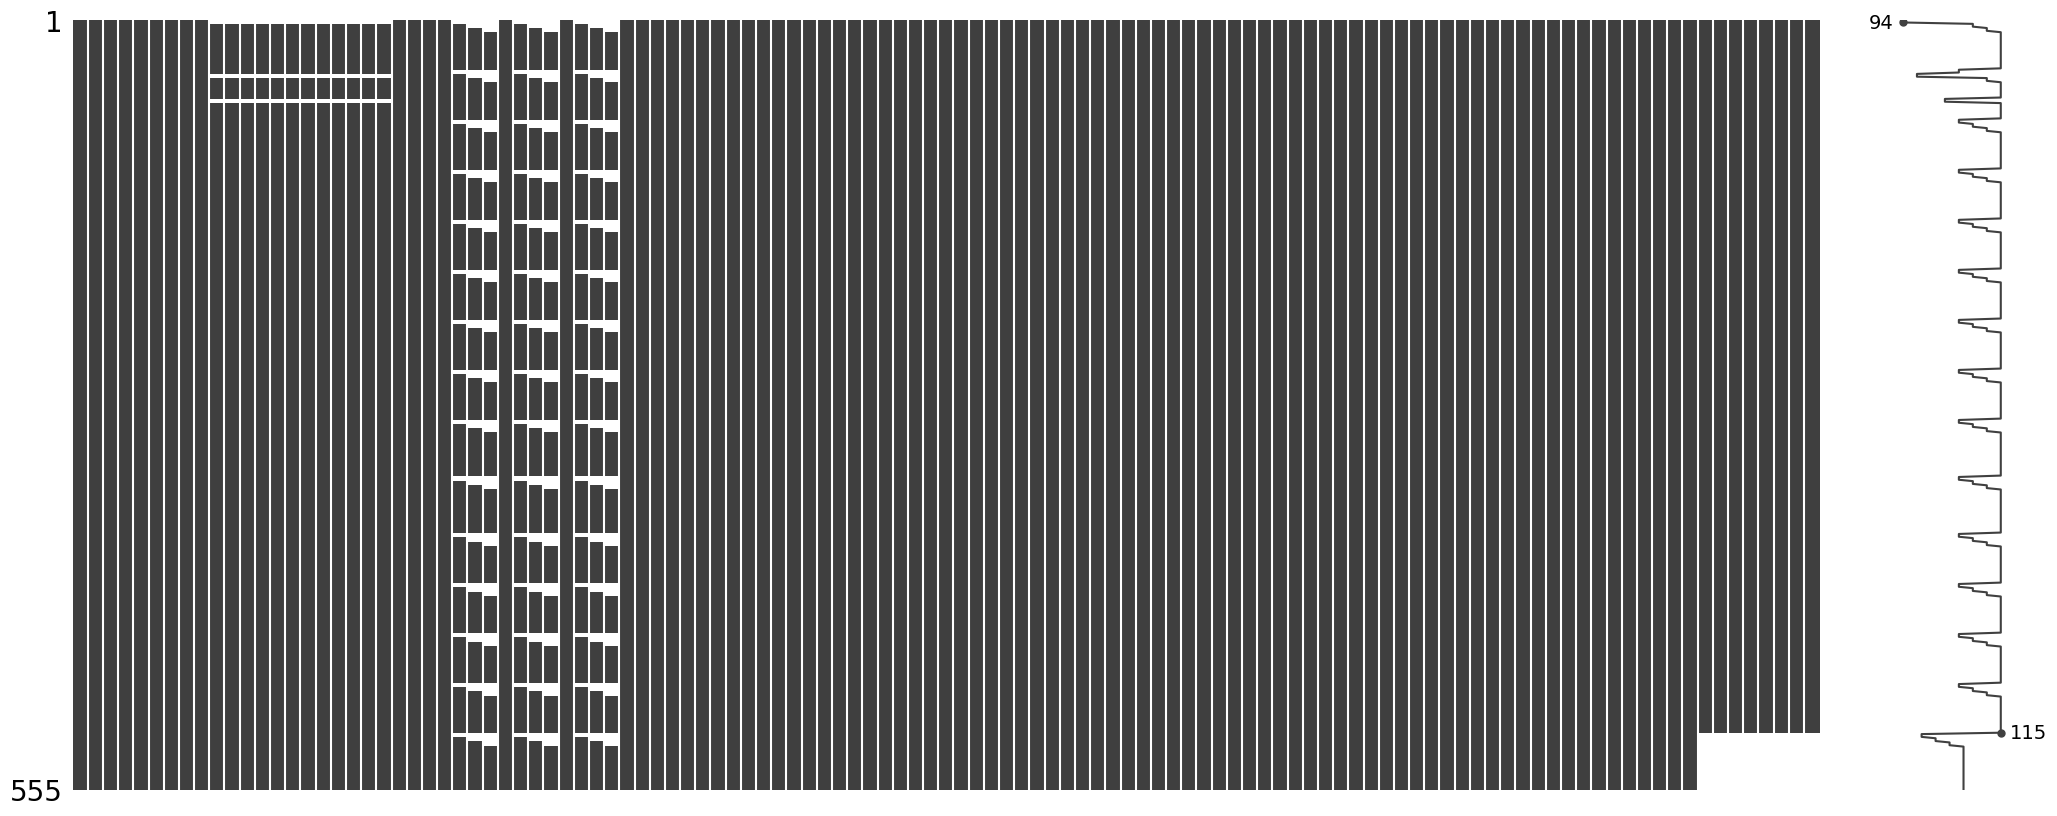

In [107]:
missingno.matrix(dataset)

In [108]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [109]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [110]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [111]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [112]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

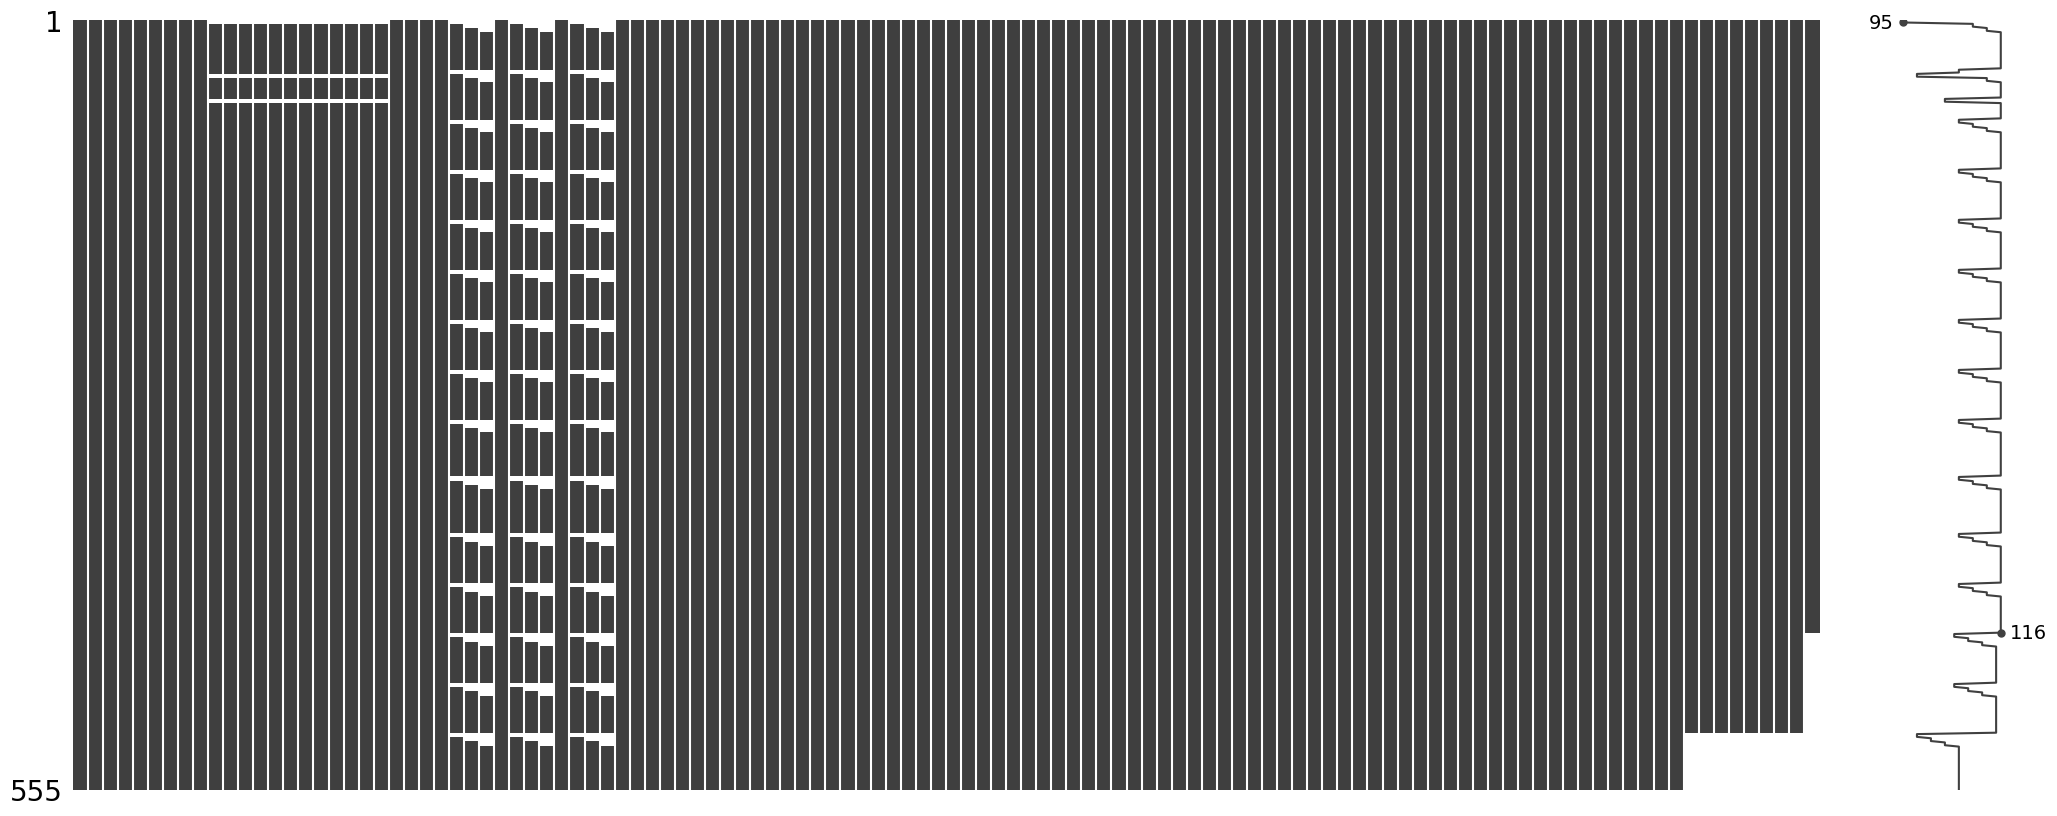

In [113]:
missingno.matrix(dataset)

In [114]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [115]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [116]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [117]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [118]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

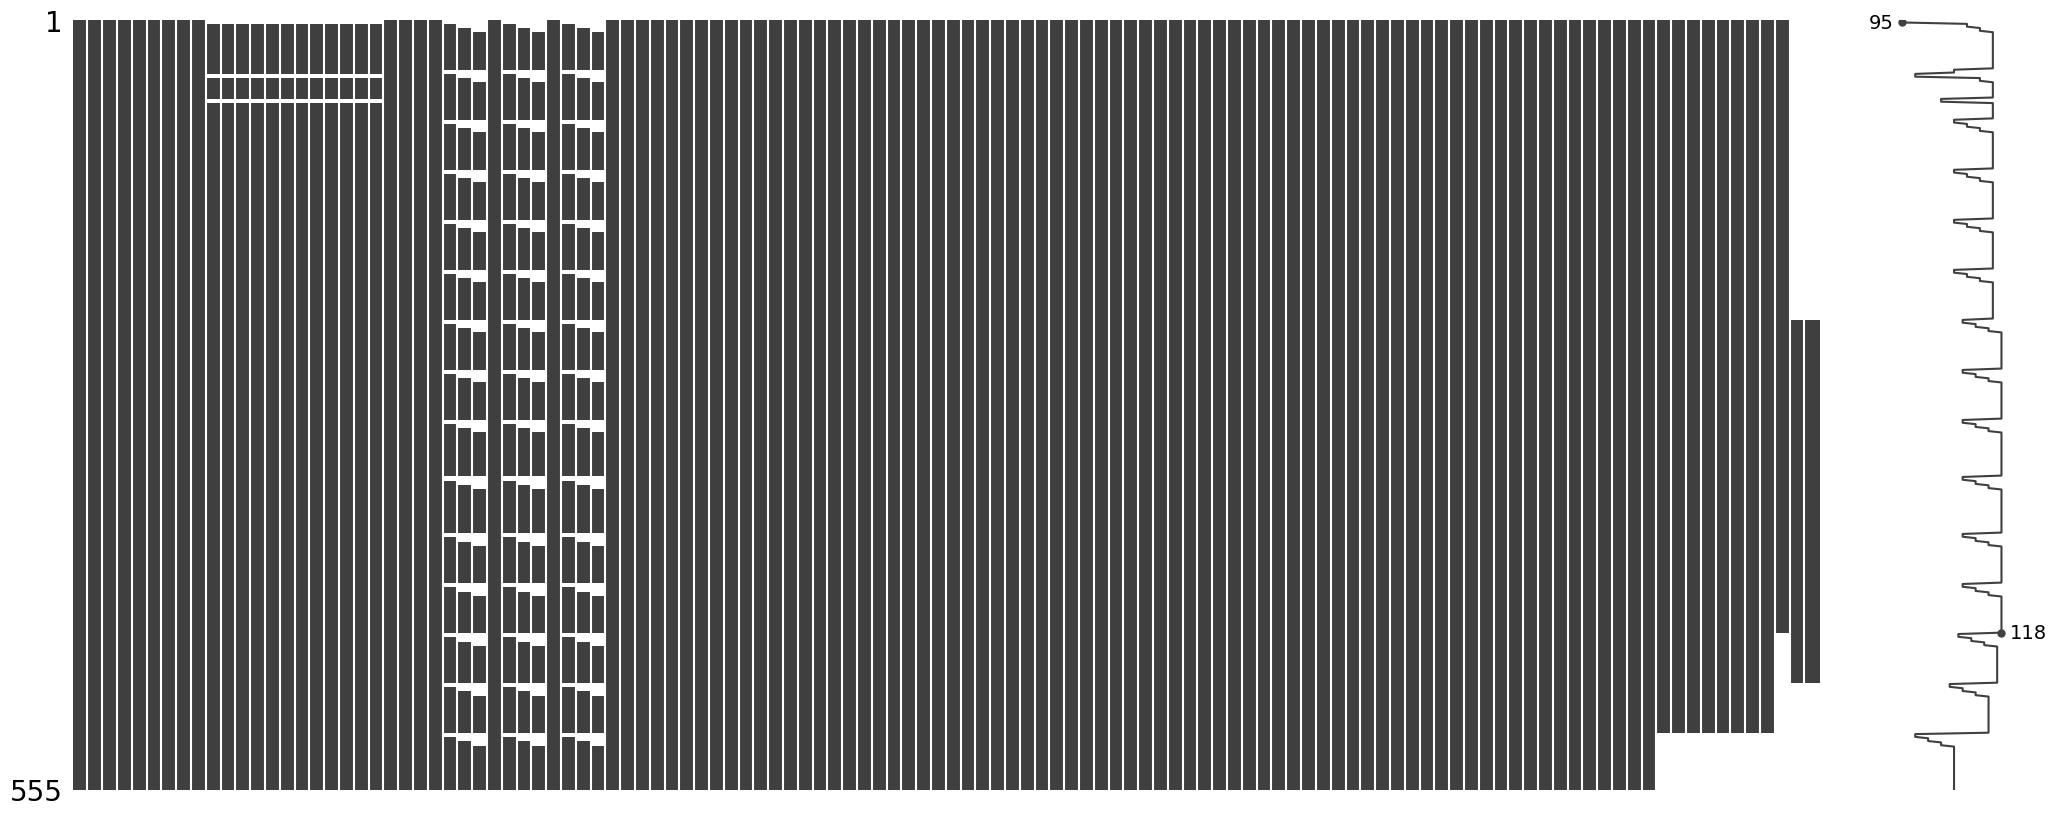

In [119]:
missingno.matrix(dataset)

In [120]:
missing = describe_dataframe(dataset)

In [121]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
113,F_Y_GE65,7.387400
114,F_TOTAL,7.387400
115,MIO_EUR,20.360400
116,L_TOTAL,52.792800


In [122]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.794372,2.906276,5.850324,8.798801,NaN,NaN,NaN,3.135829,NaN,NaN,NaN,5.967315,NaN,NaN,NaN,10.544655,97.275135,162.097517,326.486088,326.884315,325.385350,10.496302,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315,0,16.541667,20.083333,42.730496,870.594972,45.000000,-2.000000,47.000000,6.833333,27.833333,27.833333,6.833333,1562.000000,326.000000,12.000000,72.771443,683.000000,74.000000,74.000000,683.000000,13006.000000,61418.000000,20061.000000,94485.000000,12847.000000,57546.000000,23167.000000,93560.000000,3584.390000,NaN,NaN
1,2009-01,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.894878,3.788358,5.841618,7.915540,NaN,NaN,NaN,4.144929,NaN,NaN,NaN,6.030234,NaN,NaN,NaN,9.150209,57.888997,130.297894,282.936824,283.656469,279.573034,9.018485,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,31,20,30,9,9,1,1,1,2,0.961290,12.433820,283.656469,0,16.708333,20.083333,43.659420,877.615140,45.000000,-1.000000,46.000000,7.166667,28.166667,28.166667,6.833333,1438.000000,283.000000,16.000000,70.846963,625.000000,69.000000,69.000000,614.000000,11064.000000,48335.000000,13835.000000,73234.000000,10713.000000,46970.000000,15666.000000,73349.000000,2491.260000,NaN,NaN
2,2009-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.303892,36.998594,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.877874,5.112057,7.994965,10.877874,NaN,NaN,NaN,5.175483,NaN,NaN,NaN,8.026678,NaN,NaN,NaN,2.382990,22.702147,30.768818,73.854602,73.872681,952.162866,30.714931,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.000000,1.000000,33187.044169,4566.578852,52,312.154021,1632.386902,220.135393,0.000000,839.669847,7776.311459,953.263755,10.13

In [123]:
dataset.reset_index(inplace=True, drop=True)

In [124]:
dataset['cases'].value_counts()

cases
0     546
1       5
2       2
30      1
6       1
Name: count, dtype: int64

In [125]:
dataset['cases'].sum()

45

In [126]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",22.468935,37.523367,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.794372,2.906276,5.850324,8.798801,NaN,NaN,NaN,3.135829,NaN,NaN,NaN,5.967315,NaN,NaN,NaN,10.544655,97.275135,162.097517,326.486088,326.884315,325.385350,10.496302,11822.299858,1369.518699,14.608280,178.955435,672.067358,180.475196,0.001491,40.334347,161.346303,2.484012,0,33.961507,9.807387,131.548032,0.000000,1.000000,30223.665792,4645.401704,42,328.684007,1648.915382,226.308938,0.468286,3407.526380,6362.356714,950.036792,9.908659,59.612108,342.474145,14.664760,0.026427,241.108019,31,20,20,9,9,4,1,1,2,-0.005235,12.169443,326.884315,0,16.541667,20.083333,42.730496,870.594972,45.000000,-2.000000,47.000000,6.833333,27.833333,27.833333,6.833333,1562.000000,326.000000,12.000000,72.771443,683.000000,74.000000,74.000000,683.000000,13006.000000,61418.000000,20061.000000,94485.000000,12847.000000,57546.000000,23167.000000,93560.000000,3584.390000,NaN,NaN
1,2009-01,EL65,πελοποννησος,EL652,κορινθια,22.674305,37.912693,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.894878,3.788358,5.841618,7.915540,NaN,NaN,NaN,4.144929,NaN,NaN,NaN,6.030234,NaN,NaN,NaN,9.150209,57.888997,130.297894,282.936824,283.656469,279.573034,9.018485,8692.596104,1415.689869,14.865169,161.027749,624.537292,176.126818,0.000000,39.084520,2628.106643,38.115455,1,51.056323,45.272061,141.900829,0.000000,1.000000,18075.662261,3868.076282,46,323.361327,1907.721614,226.318415,0.000000,1375.629362,4104.476942,1022.868432,10.313485,64.097714,422.931298,17.198457,0.000000,159.429337,31,20,30,9,9,1,1,1,2,0.961290,12.433820,283.656469,0,16.708333,20.083333,43.659420,877.615140,45.000000,-1.000000,46.000000,7.166667,28.166667,28.166667,6.833333,1438.000000,283.000000,16.000000,70.846963,625.000000,69.000000,69.000000,614.000000,11064.000000,48335.000000,13835.000000,73234.000000,10713.000000,46970.000000,15666.000000,73349.000000,2491.260000,NaN,NaN
2,2009-01,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",22.303892,36.998594,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.877874,5.112057,7.994965,10.877874,NaN,NaN,NaN,5.175483,NaN,NaN,NaN,8.026678,NaN,NaN,NaN,2.382990,22.702147,30.768818,73.854602,73.872681,952.162866,30.714931,12283.543106,1371.533098,13.657980,173.622576,462.487528,180.406237,0.000000,24.844961,1837.803022,14.353368,0,47.835132,2.194627,120.510224,0.000000,1.000000,33187.044169,4566.578852,52,312.154021,1632.386902,220.135393,0.000000,839.669847,7776.311459,953.263755,10.13

In [127]:
cols = dataset.columns

In [128]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=118)


In [129]:
len(cols)

118

In [130]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc, index = False)
